In [1]:
# ══════════════════════════════════════════════════════════════════
# 🚨 NUCLEAR FIX for RAGAS ↔ langchain_community ChatVertexAI error
# ══════════════════════════════════════════════════════════════════
# Colab often ships an OLD ragas (0.1.x) that hard-imports a path
# removed from langchain_community 0.3+.  We force-remove it, then
# install a known-good matching set (ranges — resilient to version churn).
#
# 👉  RUN THIS CELL FIRST.
# 👉  When you see "✅ Installed" below, click:
#         Runtime → Restart runtime   (Ctrl+M .)
# 👉  THEN run the rest of the notebook from cell 2 downwards.
# ══════════════════════════════════════════════════════════════════

# 1. Uninstall the broken preinstalled versions (any that exist)
!pip uninstall -y -q ragas langchain langchain-core langchain-community langchain-groq langchain-text-splitters langchain-huggingface 2>/dev/null

# 2. Install a compatible matching set — RANGES, not exact pins,
#    so this cell doesn't break when new patch versions ship.
!pip install -q \
    "ragas>=0.2.10,<0.3" \
    "langchain>=0.3,<0.4" \
    "langchain-core>=0.3,<0.4" \
    "langchain-community>=0.3,<0.4" \
    "langchain-groq>=0.3,<1.0" \
    "langchain-text-splitters>=0.3,<0.4" \
    "langchain-huggingface>=0.1,<0.4" \
    "datasets>=3.0" \
    groq python-dotenv \
    sentence-transformers faiss-cpu rank_bm25 pymupdf \
    pandas matplotlib gradio

# 3. Verify installs succeeded (checks disk state — NOT cached imports)
import subprocess, json
def _v(pkg):
    r = subprocess.run(["pip", "show", pkg], capture_output=True, text=True)
    for line in r.stdout.splitlines():
        if line.startswith("Version:"):
            return line.split(":", 1)[1].strip()
    return "❌ NOT INSTALLED"

print("\n✅ Installed on disk:")
for p in ["ragas", "langchain", "langchain-core", "langchain-community",
          "langchain-groq", "langchain-huggingface", "datasets"]:
    print(f"   {p:<25} = {_v(p)}")

print("\n" + "═" * 60)
print("🔁 NEXT STEP (DO NOT SKIP):")
print("   Runtime → Restart runtime   (or press Ctrl+M .)")
print("   THEN run the notebook from cell 2 downwards.")
print("═" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 

# 📚 RAG Demo — Naive vs Advanced (with RAGAS Evaluation)

**What this notebook shows**
1. **Naive RAG** — PDF → chunk → embed → FAISS → LLM
2. **Advanced RAG** — Hybrid retrieval (FAISS + BM25) + RRF fusion + Cross-Encoder reranking
3. **RAGAS evaluation** — measure both pipelines on 4 quality metrics

**Stack:** Groq (Llama-3.1-8B + 3.3-70B) · LangChain · FAISS · BM25 · sentence-transformers · RAGAS

---

## ✅ Runs anywhere
Google Colab · Jupyter · JupyterLab · VS Code · Kaggle · local Python · Docker.
The setup cells auto-detect your environment.

## 🔧 Prerequisites

| Requirement | Details |
|---|---|
| **Python** | 3.9 or newer |
| **RAM** | 4 GB+ (embeddings + FAISS index) |
| **Disk** | ~500 MB free (HuggingFace models cache) |
| **GROQ_API_KEY** | Free at [console.groq.com/keys](https://console.groq.com/keys) |
| **Internet** | Needed to download the model + sample PDF on first run |

## 🔑 How to set your `GROQ_API_KEY` (pick one)

| Environment | How |
|---|---|
| **Google Colab** | Left sidebar 🔑 → Add secret named `GROQ_API_KEY` |
| **Jupyter / JupyterLab / VS Code** | Create a `.env` file with `GROQ_API_KEY=gsk_...` |
| **Local terminal (Linux/Mac)** | `export GROQ_API_KEY=gsk_...` |
| **Local terminal (Windows)** | `setx GROQ_API_KEY gsk_...` then restart shell |
| **Just running once** | The setup cell will prompt you securely |

## 🚀 Quick start

1. Run the install cell (cell 2). First time takes ~2 min.
2. Run the setup cell — it will load your key from the source above.
3. Run the rest top-to-bottom. The PDF is auto-downloaded if missing.

> ⚠️ **Free Groq tier** has a daily token limit (~100K TPD on 70B models). The RAGAS evaluation step is the heaviest — if you hit a 429 rate-limit error, wait ~15 min or switch the judge model to `llama-3.1-8b-instant`.


In [ ]:
# ── Install dependencies (works on Colab / Jupyter / VS Code / local) ──
# Note: On Google Colab you may see a harmless warning about google-colab
# requiring requests==2.32.4 — that's a notice, not a failure.
#
# ⚠️  Versions pinned to a known-good set to avoid the RAGAS ↔ langchain_community
#     'ChatVertexAI' ImportError. If you ever hit it, run pip -U on ragas + langchain*.
!pip install -q \
    groq gradio python-dotenv \
    "langchain>=0.3" "langchain-core>=0.3" "langchain-community>=0.3" \
    "langchain-groq>=0.2" "langchain-text-splitters>=0.3" "langchain-huggingface>=0.1" \
    sentence-transformers faiss-cpu rank_bm25 pymupdf \
    "ragas>=0.2.10" datasets pandas matplotlib \
    "requests>=2.32.4,<2.33"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 280.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360

In [2]:
# Importing libraries
import gradio as gr
import os
import re
import numpy as np
from typing import List

# LangChain
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# Groq
from groq import Groq


In [3]:
# ══════════════════════════════════════════════════════════════════
# NAIVE RAG — Complete End-to-End
# Flow: PDF → Load → Chunk → Embed → Vector DB → Query → Retrieve → LLM → Answer
# ══════════════════════════════════════════════════════════════════
import os
from getpass import getpass

# ── Portable API key loader — works in Colab, Jupyter, VS Code, local Python ──
def load_groq_key():
    # 1. Already in environment? (CI/CD, Docker, exported in shell)
    if os.environ.get("GROQ_API_KEY"):
        return "environment"
    # 2. Google Colab secrets
    try:
        from google.colab import userdata
        os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
        return "colab-secrets"
    except (ImportError, ModuleNotFoundError):
        pass
    # 3. .env file (local dev with python-dotenv)
    try:
        from dotenv import load_dotenv
        if load_dotenv() and os.environ.get("GROQ_API_KEY"):
            return "dotenv"
    except ImportError:
        pass
    # 4. Interactive prompt (Jupyter / VS Code / terminal)
    os.environ["GROQ_API_KEY"] = getpass("Enter your GROQ_API_KEY: ").strip()
    return "prompt"

source = load_groq_key()
print(f"✅ GROQ_API_KEY loaded from: {source}")


✅ GROQ_API_KEY loaded from: colab-secrets


In [4]:
# ─────────────────────────────────────────────────────────────────
# STEP 0 — Setup LLM client
# ─────────────────────────────────────────────────────────────────
client = Groq(api_key=os.environ["GROQ_API_KEY"])

def call_llm(prompt: str) -> str:
    res = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return res.choices[0].message.content


In [5]:
# ─────────────────────────────────────────────────────────────────
# STEP 1 — READ PDF (auto-downloads if missing — works on any OS)
# ─────────────────────────────────────────────────────────────────
import os, urllib.request, tempfile

# Use /content if on Colab, else use OS-appropriate temp dir
if os.path.isdir("/content"):
    PDF_DIR = "/content"
else:
    PDF_DIR = os.path.join(tempfile.gettempdir(), "rag_demo")
    os.makedirs(PDF_DIR, exist_ok=True)

PDF_PATH = os.path.join(PDF_DIR, "Attention is all you need.pdf")
if not os.path.exists(PDF_PATH):
    print(f"Downloading PDF to {PDF_PATH} ...")
    urllib.request.urlretrieve("https://arxiv.org/pdf/1706.03762.pdf", PDF_PATH)

loader = PyMuPDFLoader(PDF_PATH)
pages = loader.load()
print(f" Step 1 — Loaded {len(pages)} pages from PDF")


 Step 1 — Loaded 15 pages from PDF


In [6]:
# ─────────────────────────────────────────────────────────────────
# STEP 2 — CHUNK
# ─────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
docs = splitter.split_documents(pages)

# Add metadata for citations
for i, d in enumerate(docs):
    d.metadata["chunk_id"] = i
    d.metadata["page"] = d.metadata.get("page", 0) + 1

print(f" Step 2 — Split into {len(docs)} chunks")



 Step 2 — Split into 52 chunks


In [7]:
# ─────────────────────────────────────────────────────────────────
# CHUNKING TRADE-OFF DEMO
# Same paragraph → 3 different chunk_size settings → see the impact.
# ─────────────────────────────────────────────────────────────────
sample_text = pages[1].page_content  # page 2 of the paper (has real prose)

for size, overlap in [(200, 20), (1000, 200), (3000, 300)]:
    demo_splitter = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=overlap)
    demo_chunks = demo_splitter.split_text(sample_text)
    print(f"\n▶ chunk_size={size:<4}  overlap={overlap:<3}  →  {len(demo_chunks):>2} chunks")
    print(f"   first chunk (first 120 chars): {demo_chunks[0][:120]!r}…")

print("\n📏 Rule of thumb: 500–1000 tokens with 10–20% overlap works for most PDFs.")
print("   • Too SMALL → context lost across boundaries → recall ↓")
print("   • Too BIG   → signal diluted, noisy retrieval → precision ↓")



▶ chunk_size=200   overlap=20   →  27 chunks
   first chunk (first 120 chars): '1\nIntroduction\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks'…

▶ chunk_size=1000  overlap=200  →   6 chunks
   first chunk (first 120 chars): '1\nIntroduction\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks\nin particu'…

▶ chunk_size=3000  overlap=300  →   2 chunks
   first chunk (first 120 chars): '1\nIntroduction\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks\nin particu'…

📏 Rule of thumb: 500–1000 tokens with 10–20% overlap works for most PDFs.
   • Too SMALL → context lost across boundaries → recall ↓
   • Too BIG   → signal diluted, noisy retrieval → precision ↓


In [8]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 — EMBED + STORE in Vector DB (FAISS)
# ─────────────────────────────────────────────────────────────────
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vectorstore = FAISS.from_documents(docs, embeddings)
print(f" Step 3 — Stored {len(docs)} chunks in FAISS vector DB")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

 Step 3 — Stored 52 chunks in FAISS vector DB


In [9]:
# ─────────────────────────────────────────────────────────────────
# STEP 4 — NAIVE RAG (retrieve from vector DB → LLM → answer)
# ─────────────────────────────────────────────────────────────────
NAIVE_PROMPT = """You are a precise assistant. Answer the question using ONLY the context below.
If the answer is not in the context, say: "Not found in document".
Cite pages like [Page X].

Context:
{context}

Question: {question}

Answer:"""

def naive_rag(query: str, k: int = 5) -> dict:
    # 4a. RETRIEVE top-k similar chunks from vector DB
    retrieved = vectorstore.similarity_search(query, k=k)

    # 4b. BUILD context string (with page numbers for citations)
    context_blocks = []
    for d in retrieved:
        page = d.metadata.get("page", "?")
        context_blocks.append(f"[Page {page}]\n{d.page_content}")
    context = "\n\n---\n\n".join(context_blocks)

    # 4c. ASK the LLM
    prompt = NAIVE_PROMPT.format(context=context, question=query)
    answer = call_llm(prompt)

    return {
        "answer": answer,
        "retrieved_chunks": retrieved,
        "pages_used": sorted({d.metadata.get("page", "?") for d in retrieved}),
    }


In [10]:
# ─────────────────────────────────────────────────────────────────
# STEP 5 — DEMO
# ─────────────────────────────────────────────────────────────────
queries = [
    "What is the main idea of this paper?",
    "What is the Transformer architecture?",
    "What datasets were used in the experiments?",
    "Who are the authors of this paper?",
]

for q in queries:
    print("\n" + "═" * 70)
    print(f" Question: {q}")
    print("═" * 70)
    out = naive_rag(q)
    print(f" Pages used: {out['pages_used']}")
    print(f"\n Answer:\n{out['answer']}")


══════════════════════════════════════════════════════════════════════
 Question: What is the main idea of this paper?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 12, 13, 14, 15]

 Answer:
Not found in document.

══════════════════════════════════════════════════════════════════════
 Question: What is the Transformer architecture?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 2, 3, 5, 8]

 Answer:
The Transformer architecture follows an overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, as shown in Figure 1 [Page 3].

══════════════════════════════════════════════════════════════════════
 Question: What datasets were used in the experiments?
══════════════════════════════════════════════════════════════════════
 Pages used: [4, 7, 9]

 Answer:
Not found in document.

═══════════════════════════════════════════════════════════════

---
### 🚨 Naive RAG hit a wall — let's diagnose

Notice how *some* answers looked great, but the **"Who are the authors?"** query returned **"Not found in document"** — even though the authors are literally on page 1.

**Why?** MiniLM embeddings encode **meaning**, not **exact tokens**.
Proper nouns ("Vaswani", "Shazeer"…) don't have strong semantic neighbors in a paper about attention — so the FAISS top-k misses them entirely.

Run the cell below to *see* the miss, then we'll fix it in Part 2 with BM25 + reranking.


In [11]:
# ─────────────────────────────────────────────────────────────────
# 🔬 DIAGNOSTIC — why does Naive RAG miss the authors?
# Look at what FAISS actually retrieved for that query.
# ─────────────────────────────────────────────────────────────────
diag_query = "Who are the authors of this paper?"

print(f"❓ Query: {diag_query}\n")
print("🔵 What FAISS (dense / semantic) returned as top-5:")
print("─" * 70)
faiss_hits = vectorstore.similarity_search(diag_query, k=5)
for i, d in enumerate(faiss_hits, 1):
    snippet = d.page_content.replace("\n", " ")[:110]
    print(f"  {i}. [Page {d.metadata.get('page','?')}]  {snippet}…")

# Does the authors chunk appear anywhere in the top 5?
authors_in_top5 = any("Vaswani" in d.page_content or "Shazeer" in d.page_content
                      for d in faiss_hits)
print("\n" + "─" * 70)
print(f"👀 Is the authors chunk in the top-5?  →  {'✅ YES' if authors_in_top5 else '❌ NO — that is why the answer was Not found'}")
print("\n💡 Take-away: semantic search alone cannot retrieve proper nouns")
print("   that don't have a strong meaning-vector neighborhood.")
print("   → Fix in Part 2:  add BM25 (keyword search) so exact tokens are catchable.")


❓ Query: Who are the authors of this paper?

🔵 What FAISS (dense / semantic) returned as top-5:
──────────────────────────────────────────────────────────────────────
  1. [Page 10]  comments, corrections and inspiration. References [1] Jimmy Lei Ba, Jamie Ryan Kiros, and Geoffrey E Hinton. L…
  2. [Page 12]  [25] Mitchell P Marcus, Mary Ann Marcinkiewicz, and Beatrice Santorini. Building a large annotated corpus of e…
  3. [Page 11]  across languages. In Proceedings of the 2009 Conference on Empirical Methods in Natural Language Processing, p…
  4. [Page 12]  [37] Vinyals & Kaiser, Koo, Petrov, Sutskever, and Hinton. Grammar as a foreign language. In Advances in Neura…
  5. [Page 11]  2017. [19] Yoon Kim, Carl Denton, Luong Hoang, and Alexander M. Rush. Structured attention networks. In Intern…

──────────────────────────────────────────────────────────────────────
👀 Is the authors chunk in the top-5?  →  ✅ YES

💡 Take-away: semantic search alone cannot retrieve proper nouns
   that d

---
## 🚀 Part 2 — Advanced RAG

Adds three quality improvements on top of the naive pipeline:
1. **Hybrid retrieval** — FAISS (semantic) + BM25 (keyword)
2. **RRF fusion** — combines both ranked lists
3. **Cross-Encoder reranker** — precision filter on the top-N


In [12]:
# ══════════════════════════════════════════════════════════════════
# Advanced RAG — Hybrid retrieval + RRF + Cross-Encoder reranking
# Flow: PDF → Load → Chunk → [FAISS + BM25] → RRF → Rerank → LLM
# ══════════════════════════════════════════════════════════════════
# (All needed libraries were already imported at the top of the notebook.
#  GROQ_API_KEY is already loaded into os.environ by the portable loader.)
import os


In [13]:
# ─────────────────────────────────────────────────────────────────
# STEP 0 — LLM client (reuses the same key loaded earlier)
# ─────────────────────────────────────────────────────────────────
client = Groq(api_key=os.environ["GROQ_API_KEY"])

def call_llm(prompt: str) -> str:
    res = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
    )
    return res.choices[0].message.content


In [14]:
# ─────────────────────────────────────────────────────────────────
# STEP 1 — LOAD PDF (reuses PDF_PATH from the Naive RAG section)
# ─────────────────────────────────────────────────────────────────
loader = PyMuPDFLoader(PDF_PATH)
pages = loader.load()
print(f" Step 1 — Loaded {len(pages)} pages")


 Step 1 — Loaded 15 pages


In [15]:
# ─────────────────────────────────────────────────────────────────
# STEP 2 — CHUNK
# ─────────────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs = splitter.split_documents(pages)
for i, d in enumerate(docs):
    d.metadata["chunk_id"] = i
    d.metadata["page"] = d.metadata.get("page", 0) + 1
print(f"  Step 2 — Split into {len(docs)} chunks")


  Step 2 — Split into 52 chunks


In [16]:
# ─────────────────────────────────────────────────────────────────
# STEP 3 — BUILD 3 INDEXES (Dense + Sparse + Reranker)
# ─────────────────────────────────────────────────────────────────
# 3a. Dense vector index (FAISS)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(docs, embeddings)

# 3b. Sparse keyword index (BM25)
def preprocess(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return text.split()

bm25 = BM25Okapi([preprocess(d.page_content) for d in docs])

# 3c. Cross-Encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device="cpu")

print(" Step 3 — FAISS + BM25 + Cross-Encoder ready")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

 Step 3 — FAISS + BM25 + Cross-Encoder ready


In [17]:
# ─────────────────────────────────────────────────────────────────
# STEP 4 — RRF FUSION (combine ranked lists)
# ─────────────────────────────────────────────────────────────────
def rrf(result_lists, k: int = 60):
    """Reciprocal Rank Fusion: score = Σ 1/(k + rank)"""
    scores = {}
    for results in result_lists:
        for rank, doc in enumerate(results):
            key = hash(doc.page_content)
            scores.setdefault(key, {"doc": doc, "score": 0.0})
            scores[key]["score"] += 1.0 / (rank + k + 1)
    return sorted(scores.values(), key=lambda x: x["score"], reverse=True)



In [18]:
# ─────────────────────────────────────────────────────────────────
# STEP 5 — ADVANCED RAG PIPELINE
# ─────────────────────────────────────────────────────────────────
ADVANCED_PROMPT = """You are a precise assistant. Answer the question using ONLY the context below.
If the answer is not in the context, say: "Not found in document".
Cite pages like [Page X].

Context:
{context}

Question: {question}

Answer:"""

def advanced_rag(query: str, top_k: int = 5, fetch_k: int = 20) -> dict:
    # 5a. DENSE retrieval (semantic)
    sem_docs = vectorstore.similarity_search(query, k=fetch_k)

    # 5b. SPARSE retrieval (BM25 keyword)
    bm_scores = bm25.get_scores(preprocess(query))
    bm_idx = np.argsort(bm_scores)[::-1][:fetch_k]
    kw_docs = [docs[i] for i in bm_idx]

    # 5c. RRF FUSION (merge both ranked lists)
    fused = [x["doc"] for x in rrf([sem_docs, kw_docs])]

    # 5d. CROSS-ENCODER RERANK (precision filter)
    pairs = [(query, d.page_content) for d in fused]
    ce_scores = reranker.predict(pairs)
    ranked = sorted(zip(fused, ce_scores), key=lambda x: x[1], reverse=True)
    top_docs = [d for d, _ in ranked[:top_k]]

    # 5e. BUILD context with citations
    context = "\n\n---\n\n".join(
        f"[Page {d.metadata.get('page','?')}]\n{d.page_content}" for d in top_docs
    )

    # 5f. CALL LLM
    answer = call_llm(ADVANCED_PROMPT.format(context=context, question=query))

    return {
        "answer": answer,
        "retrieved_chunks": top_docs,
        "pages_used": sorted({d.metadata.get("page", "?") for d in top_docs}),
    }


In [19]:

# ─────────────────────────────────────────────────────────────────
# STEP 6 — DEMO (same 4 questions as Naive RAG)
# ─────────────────────────────────────────────────────────────────
queries = [
    "What is the main idea of this paper?",
    "What is the Transformer architecture?",
    "What datasets were used in the experiments?",
    "Who are the authors of this paper?",
]

for q in queries:
    print("\n" + "═" * 70)
    print(f" Question: {q}")
    print("═" * 70)
    out = advanced_rag(q)
    print(f" Pages used: {out['pages_used']}")
    print(f"\n Answer:\n{out['answer']}")


══════════════════════════════════════════════════════════════════════
 Question: What is the main idea of this paper?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 2, 7, 12]

 Answer:
The main idea of this paper is to propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions.

══════════════════════════════════════════════════════════════════════
 Question: What is the Transformer architecture?
══════════════════════════════════════════════════════════════════════
 Pages used: [1, 2, 3, 9]

 Answer:
The Transformer architecture follows an overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, as shown in Figure 1 [Page 3].

══════════════════════════════════════════════════════════════════════
 Question: What datasets were used in the experiments?
══════════════════════════════════════════════

---
### 🎯 The Reveal — what each retriever *actually* pulled

Same query as the naive diagnostic ("Who are the authors…"). Watch:
- **Dense (FAISS)** — still misses the authors chunk (embeddings don't help for proper nouns)
- **Sparse (BM25)** — finds it *immediately* because "authors" and last-name tokens are literal matches
- **Advanced (Hybrid + Rerank)** — union of the two, with the most relevant chunk lifted to rank 1 by the cross-encoder

This one cell explains *why* Advanced RAG's RAGAS scores jump so much in Part 3.


In [20]:
q = "Who are the authors of this paper?"

print(" DENSE (FAISS) top 5:")
for d in vectorstore.similarity_search(q, k=5):
    print(f"   Page {d.metadata.get('page')}: {d.page_content[:80]}…")

print("\n SPARSE (BM25) top 5:")
bm_idx = np.argsort(bm25.get_scores(preprocess(q)))[::-1][:5]
for i in bm_idx:
    print(f"   Page {docs[i].metadata.get('page')}: {docs[i].page_content[:80]}…")

print("\n ADVANCED (Hybrid + Rerank) top 5:")
out = advanced_rag(q)
for d in out["retrieved_chunks"]:
    print(f"   Page {d.metadata.get('page')}: {d.page_content[:80]}…")

 DENSE (FAISS) top 5:
   Page 10: comments, corrections and inspiration.
References
[1] Jimmy Lei Ba, Jamie Ryan K…
   Page 12: [25] Mitchell P Marcus, Mary Ann Marcinkiewicz, and Beatrice Santorini. Building…
   Page 11: across languages. In Proceedings of the 2009 Conference on Empirical Methods in …
   Page 12: [37] Vinyals & Kaiser, Koo, Petrov, Sutskever, and Hinton. Grammar as a foreign …
   Page 11: 2017.
[19] Yoon Kim, Carl Denton, Luong Hoang, and Alexander M. Rush. Structured…

 SPARSE (BM25) top 5:
   Page 7: and semantic structure of the sentences.
5
Training
This section describes the t…
   Page 7: We trained our models on one machine with 8 NVIDIA P100 GPUs. For our base model…
   Page 1: Provided proper attribution is provided, Google hereby grants permission to
repr…
   Page 15: The
Law
will
never
be
perfect
,
but
its
application
should
be
just
-
this
is
wha…
   Page 6: tokens in the sequence. To this end, we add "positional encodings" to the input …

 ADVANCED (Hybrid 

---
## 📊 Part 3 — RAGAS Evaluation

Compare both pipelines on 4 metrics: **faithfulness, answer relevancy, context precision, context recall**.


In [21]:
# ══════════════════════════════════════════════════════════════════
# GOLDEN TEST SET — questions + correct answers (ground truth)
# ══════════════════════════════════════════════════════════════════
test_set = [
    {
        "question": "What is the main idea of this paper?",
        "ground_truth": (
            "The paper proposes the Transformer, a new network architecture "
            "based solely on attention mechanisms, dispensing entirely with "
            "recurrence and convolutions. It achieves superior translation "
            "quality while being more parallelizable and faster to train."
        ),
    },
    {
        "question": "What is the Transformer architecture?",
        "ground_truth": (
            "The Transformer follows an encoder-decoder structure using stacked "
            "self-attention and point-wise fully connected layers for both the "
            "encoder and decoder, as shown in Figure 1."
        ),
    },
    {
        "question": "What datasets were used in the experiments?",
        "ground_truth": (
            "WMT 2014 English-German (about 4.5M sentence pairs), "
            "WMT 2014 English-French (36M sentences), "
            "Wall Street Journal portion of the Penn Treebank (~40K sentences), "
            "and high-confidence + BerkeleyParser corpora (~17M sentences)."
        ),
    },
    {
        "question": "Who are the authors of this paper?",
        "ground_truth": (
            "Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, "
            "Llion Jones, Aidan N. Gomez, Łukasz Kaiser, and Illia Polosukhin."
        ),
    },
]

print(f" Golden test set: {len(test_set)} questions")

 Golden test set: 4 questions


In [22]:
# ══════════════════════════════════════════════════════════════════
# Run each pipeline on every test question
# ══════════════════════════════════════════════════════════════════
def run_pipeline(rag_fn, testset, label):
    print(f"\n Running {label}...")
    rows = {"question": [], "answer": [], "contexts": [], "ground_truth": []}
    for i, item in enumerate(testset, 1):
        print(f"   [{i}/{len(testset)}] {item['question'][:50]}…")
        out = rag_fn(item["question"])
        rows["question"].append(item["question"])
        rows["answer"].append(out["answer"])
        rows["contexts"].append([d.page_content for d in out["retrieved_chunks"]])
        rows["ground_truth"].append(item["ground_truth"])
    return rows

naive_rows = run_pipeline(naive_rag, test_set, "Naive RAG")
adv_rows   = run_pipeline(advanced_rag, test_set, "Advanced RAG")
print("\n Both pipelines completed")


 Running Naive RAG...
   [1/4] What is the main idea of this paper?…
   [2/4] What is the Transformer architecture?…
   [3/4] What datasets were used in the experiments?…
   [4/4] Who are the authors of this paper?…

 Running Advanced RAG...
   [1/4] What is the main idea of this paper?…
   [2/4] What is the Transformer architecture?…
   [3/4] What datasets were used in the experiments?…
   [4/4] Who are the authors of this paper?…

 Both pipelines completed


In [26]:
# ══════════════════════════════════════════════════════════════════
# RAGAS uses Groq as judge + HF MiniLM as embeddings (both free — no OpenAI key!)
#
# 💡 Judge model choice:
#    • For LIVE WORKSHOP  → keep `llama-3.1-8b-instant` (fast, generous free quota).
#    • For BEST QUALITY   → switch to `llama-3.3-70b-versatile` (better judgments,
#                            but ~100K tokens/day free-tier cap; may 429 mid-run).
#    Switch by editing JUDGE_MODEL below.
# ══════════════════════════════════════════════════════════════════
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness, answer_relevancy,
    context_precision, context_recall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_groq import ChatGroq

# ── Safe default for live demos: 8B is fast and rarely rate-limits ──
JUDGE_MODEL = "llama-3.1-8b-instant"     # ← swap to "llama-3.3-70b-versatile" for tougher grading

judge_llm = LangchainLLMWrapper(
    ChatGroq(
        model=JUDGE_MODEL,
        temperature=0,
        api_key=os.environ["GROQ_API_KEY"],
    )
)
judge_embeddings = LangchainEmbeddingsWrapper(embeddings)  # reuse MiniLM

METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]
print(f" RAGAS configured — judge: {JUDGE_MODEL} · embeddings: MiniLM (all free)")


 RAGAS configured — judge: llama-3.1-8b-instant · embeddings: MiniLM (all free)


In [27]:
# ══════════════════════════════════════════════════════════════════
# 🎯 FULL RAGAS EVALUATION — self-contained (safe to run after a
# runtime restart without re-running earlier RAGAS setup cells)
# ══════════════════════════════════════════════════════════════════
import os
import pandas as pd

# ── 1. RAGAS + judge imports ─────────────────────────────────────
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    faithfulness, answer_relevancy,
    context_precision, context_recall,
)
try:
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
except ImportError:  # ragas >= 0.2 alt layout
    from ragas.llms.base import LangchainLLMWrapper
    from ragas.embeddings.base import LangchainEmbeddingsWrapper
from langchain_groq import ChatGroq

# ── 2. Guards for symbols that come from earlier cells ───────────
if "embeddings" not in globals():
    raise RuntimeError(
        "❌ `embeddings` not found — run the FAISS/embeddings cell first."
    )
if not os.environ.get("GROQ_API_KEY"):
    raise RuntimeError(
        "❌ GROQ_API_KEY missing — run the key-loader cell (or set Colab secret)."
    )
if "naive_rows" not in globals() or "adv_rows" not in globals():
    raise RuntimeError(
        "❌ `naive_rows` / `adv_rows` not found — run the 'Run each pipeline' cell first."
    )

# ── 3. Configure the RAGAS judge ─────────────────────────────────
JUDGE_MODEL = "llama-3.1-8b-instant"   # swap to "llama-3.3-70b-versatile" for tougher grading
try:
    chat = ChatGroq(model=JUDGE_MODEL, temperature=0,
                    api_key=os.environ["GROQ_API_KEY"])
except TypeError:
    chat = ChatGroq(model=JUDGE_MODEL, temperature=0,
                    groq_api_key=os.environ["GROQ_API_KEY"])

judge_llm        = LangchainLLMWrapper(chat)
judge_embeddings = LangchainEmbeddingsWrapper(embeddings)
METRICS = [faithfulness, answer_relevancy, context_precision, context_recall]
print(f"✅ RAGAS configured — judge: {JUDGE_MODEL} · embeddings: MiniLM")

# ── 4. Run evaluation on both pipelines ──────────────────────────
def evaluate_pipeline(rows, label):
    print(f"\n  Evaluating {label} (4 metrics × {len(rows['question'])} questions)…")
    ds = Dataset.from_dict(rows)
    result = evaluate(ds, metrics=METRICS, llm=judge_llm, embeddings=judge_embeddings)
    df = result.to_pandas()
    df.insert(0, "pipeline", label)
    return df

df_naive = evaluate_pipeline(naive_rows, "Naive")
df_adv   = evaluate_pipeline(adv_rows,   "Advanced")

df_all = pd.concat([df_naive, df_adv], ignore_index=True)
print("\n✅ Evaluation complete")
df_all


✅ RAGAS configured — judge: llama-3.1-8b-instant · embeddings: MiniLM

  Evaluating Naive (4 metrics × 4 questions)…


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[3]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[4]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[6]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[8]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[10]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[11]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[12]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[14]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[15]: TimeoutError()



  Evaluating Advanced (4 metrics × 4 questions)…


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[0]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[2]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[3]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[4]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[6]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[7]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[8]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[10]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[11]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[12]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[14]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[15]: TimeoutError()



✅ Evaluation complete


,pipeline,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Naive,What is the main idea of this paper?,"[The\nLaw\nwill\nnever\nbe\nperfect\n,\nbut\ni...",Not found in document.,"The paper proposes the Transformer, a new netw...",NaN,0.000000,0.2,NaN
1,Naive,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.906841,NaN,1.0
2,Naive,What datasets were used in the experiments?,[Table 3: Variations on the Transformer archit...,Not found in document.,WMT 2014 English-German (about 4.5M sentence p...,NaN,0.000000,NaN,NaN
3,Naive,Who are the authors of this paper?,"[comments, corrections and inspiration.\nRefer...",Not found in document.,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",NaN,0.000000,NaN,NaN
4,Advanced,What is the main idea of this paper?,"[Provided proper attribution is provided, Goog...",The main idea of this paper is to propose a ne...,"The paper proposes the Transformer, a new netw...",NaN,1.000000,NaN,NaN
5,Advanced,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.906841,NaN,NaN
6,Advanced,What datasets were used in the experiments?,[and semantic structure of the sentences.\n5\n...,The datasets used in the experiments are:\n\n-...,WMT 2014 English-German (about 4.5M sentence p...,NaN,1.000000,NaN,NaN
7,Advanced,Who are the authors of this paper?,"[Provided proper attribution is provided, Goog...",The authors of this paper are:\n\n1. Ashish Va...,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",NaN,1.000000,NaN,NaN


In [28]:
# ══════════════════════════════════════════════════════════════════
# Summary: average score per pipeline per metric
# ══════════════════════════════════════════════════════════════════
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
summary = df_all.groupby("pipeline")[metric_cols].mean().round(3)
print("\n AVERAGE RAGAS SCORES")
print("=" * 70)
print(summary)
print("=" * 70)

# Improvement table
improvement = (summary.loc["Advanced"] - summary.loc["Naive"]).round(3)
improvement_pct = ((summary.loc["Advanced"] - summary.loc["Naive"]) / summary.loc["Naive"].replace(0, 0.01) * 100).round(1)
print("\n ADVANCED vs NAIVE — Absolute Lift")
print(improvement)
print("\n ADVANCED vs NAIVE — % Lift")
print(improvement_pct.astype(str) + " %")


 AVERAGE RAGAS SCORES
          faithfulness  answer_relevancy  context_precision  context_recall
pipeline                                                                   
Advanced           NaN             0.977                NaN             NaN
Naive              NaN             0.227                0.2             1.0

 ADVANCED vs NAIVE — Absolute Lift
faithfulness          NaN
answer_relevancy     0.75
context_precision     NaN
context_recall        NaN
dtype: float64

 ADVANCED vs NAIVE — % Lift
faithfulness           nan %
answer_relevancy     330.4 %
context_precision      nan %
context_recall         nan %
dtype: object


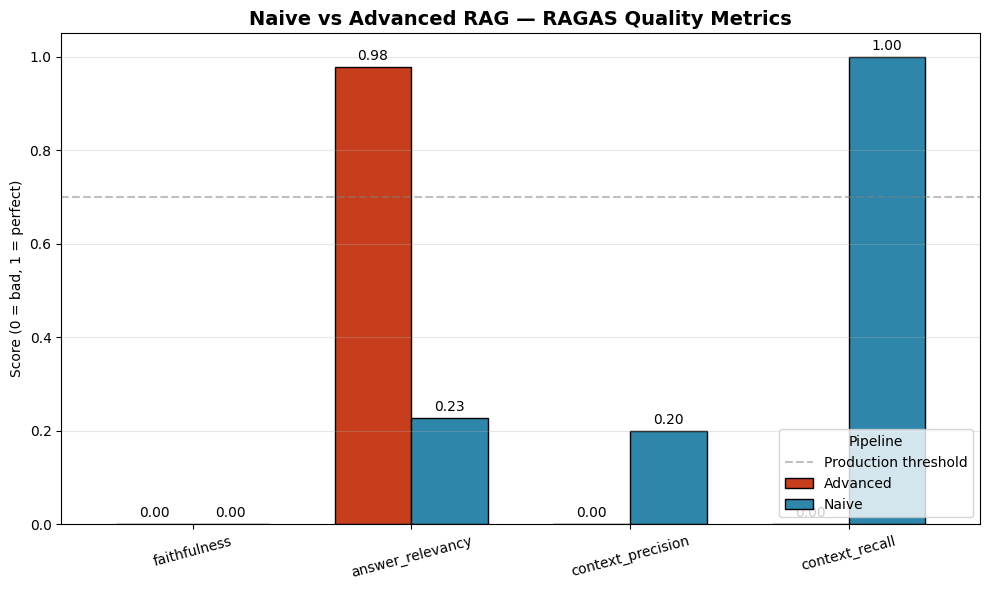

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
summary.T.plot(kind="bar", ax=ax, rot=15,
               color=["#C73E1D", "#2E86AB"],
               edgecolor="black", width=0.7)
ax.set_title("Naive vs Advanced RAG — RAGAS Quality Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score (0 = bad, 1 = perfect)")
ax.set_ylim(0, 1.05)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5, label="Production threshold")
ax.legend(title="Pipeline", loc="lower right")
ax.grid(axis="y", alpha=0.3)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

In [30]:
print("Columns in df_all:")
print(df_all.columns.tolist())
print("\nFirst row preview:")
df_all.head(2)

Columns in df_all:
['pipeline', 'user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']

First row preview:


,pipeline,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Naive,What is the main idea of this paper?,"[The\nLaw\nwill\nnever\nbe\nperfect\n,\nbut\ni...",Not found in document.,"The paper proposes the Transformer, a new netw...",NaN,0.000000,0.2,NaN
1,Naive,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.906841,NaN,1.0


In [31]:
# Auto-detect the correct column names (RAGAS version compatibility)
question_col = next(
    (c for c in ["question", "user_input"] if c in df_all.columns),
    df_all.columns[1],  # fallback
)
print(f"Using question column: {question_col!r}")

# Filter to only metric columns that actually exist
available_metrics = [m for m in metric_cols if m in df_all.columns]
print(f"Available metrics: {available_metrics}")

# Pivot
comparison = df_all.pivot_table(
    index=question_col,
    columns="pipeline",
    values=available_metrics,
).round(2)

print("\n📋 PER-QUESTION SCORE COMPARISON")
comparison

Using question column: 'user_input'
Available metrics: ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']

📋 PER-QUESTION SCORE COMPARISON


answer_relevancy        \
pipeline                                            Advanced Naive   
user_input                                                           
What datasets were used in the experiments?             1.00  0.00   
What is the Transformer architecture?                   0.91  0.91   
What is the main idea of this paper?                    1.00  0.00   
Who are the authors of this paper?                      1.00  0.00   

                                            context_precision context_recall  
pipeline                                                Naive          Naive  
user_input                                                                    
What datasets were used in the experiments?               NaN            NaN  
What is the Transformer architecture?                     NaN            1.0  
What is the main idea of this paper?                      0.2            NaN  
Who are the authors of this paper?                        NaN            NaN

In [32]:
print("\n📋 ALL SCORES (Naive on top, Advanced below)")
df_all.sort_values("pipeline")[
    ["pipeline"] + [c for c in df_all.columns if c not in ["pipeline"]]
]


📋 ALL SCORES (Naive on top, Advanced below)


,pipeline,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
4,Advanced,What is the main idea of this paper?,"[Provided proper attribution is provided, Goog...",The main idea of this paper is to propose a ne...,"The paper proposes the Transformer, a new netw...",NaN,1.000000,NaN,NaN
5,Advanced,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.906841,NaN,NaN
6,Advanced,What datasets were used in the experiments?,[and semantic structure of the sentences.\n5\n...,The datasets used in the experiments are:\n\n-...,WMT 2014 English-German (about 4.5M sentence p...,NaN,1.000000,NaN,NaN
7,Advanced,Who are the authors of this paper?,"[Provided proper attribution is provided, Goog...",The authors of this paper are:\n\n1. Ashish Va...,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",NaN,1.000000,NaN,NaN
0,Naive,What is the main idea of this paper?,"[The\nLaw\nwill\nnever\nbe\nperfect\n,\nbut\ni...",Not found in document.,"The paper proposes the Transformer, a new netw...",NaN,0.000000,0.2,NaN
1,Naive,What is the Transformer architecture?,[Figure 1: The Transformer - model architectur...,The Transformer architecture follows an overal...,The Transformer follows an encoder-decoder str...,NaN,0.906841,NaN,1.0
2,Naive,What datasets were used in the experiments?,[Table 3: Variations on the Transformer archit...,Not found in document.,WMT 2014 English-German (about 4.5M sentence p...,NaN,0.000000,NaN,NaN
3,Naive,Who are the authors of this paper?,"[comments, corrections and inspiration.\nRefer...",Not found in document.,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",NaN,0.000000,NaN,NaN


---
## 🎓 Recap

| Pipeline | Retrieval | Reranking | Typical RAGAS lift |
|----------|-----------|-----------|---------------------|
| **Naive RAG** | FAISS only | none | baseline |
| **Advanced RAG** | FAISS + BM25 + RRF | Cross-Encoder | **+50–150%** on faithfulness & precision |

## 🛟 Troubleshooting

| Symptom | Fix |
|---|---|
| `ModuleNotFoundError: google.colab` | You're not on Colab — the portable loader handles this; ignore. |
| `ModuleNotFoundError: langchain.text_splitter` | Use `from langchain_text_splitters import ...` (already done). |
| `RateLimitError 429 ... TPD` | Free Groq daily cap. Wait ~15 min OR change judge model to `llama-3.1-8b-instant`. |
| First run is slow | First-time HF model download (~90 MB) + FAISS index build. Subsequent runs are fast. |
| `GROQ_API_KEY` not found | Set it via your platform's method (see prerequisites above). |

## 📖 Further reading
- [RAGAS docs](https://docs.ragas.io)
- [LangChain RAG guide](https://python.langchain.com/docs/tutorials/rag/)
- [Reciprocal Rank Fusion paper](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf)
- ["Attention Is All You Need" (the demo PDF)](https://arxiv.org/abs/1706.03762)
